# Recommendation Systems: Content-Based and Collaborative Filtering

This notebook walks through two foundational recommendation architectures.

---
## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)

### Contrived Spotify Dataset

Eight songs described by four features:
- **artists** — who made it (categorical, multi-label)
- **tempo** — beats per minute (continuous, ~60–200)
- **energy** — perceived intensity 0–1 (continuous)
- **key** — musical key: C / D / G / A (categorical)

In [2]:
songs = pd.DataFrame([
    {"id": "S1", "name": "Get Lucky",            "artists": "Daft Punk",   "tempo": 128, "energy": 0.90, "key": "G"},
    {"id": "S2", "name": "Circles",              "artists": "Post Malone", "tempo":  98, "energy": 0.65, "key": "C"},
    {"id": "S3", "name": "Skinny Love",          "artists": "Bon Iver",    "tempo":  72, "energy": 0.25, "key": "D"},
    {"id": "S4", "name": "Harder Better Faster", "artists": "Daft Punk",   "tempo": 135, "energy": 0.95, "key": "A"},
    {"id": "S5", "name": "Holocene",             "artists": "Bon Iver",    "tempo":  80, "energy": 0.30, "key": "C"},
    {"id": "S6", "name": "Levitating",           "artists": "Dua Lipa",    "tempo": 122, "energy": 0.85, "key": "G"},
    {"id": "S7", "name": "Uptown Funk",          "artists": "Mark Ronson", "tempo": 105, "energy": 0.60, "key": "D"},
    {"id": "S8", "name": "Flume",                "artists": "Bon Iver",    "tempo":  68, "energy": 0.20, "key": "A"},
])

print("Our song catalog:")
print(songs.to_string(index=False))

Our song catalog:
id                 name     artists  tempo  energy key
S1            Get Lucky   Daft Punk    128    0.90   G
S2              Circles Post Malone     98    0.65   C
S3          Skinny Love    Bon Iver     72    0.25   D
S4 Harder Better Faster   Daft Punk    135    0.95   A
S5             Holocene    Bon Iver     80    0.30   C
S6           Levitating    Dua Lipa    122    0.85   G
S7          Uptown Funk Mark Ronson    105    0.60   D
S8                Flume    Bon Iver     68    0.20   A


---
## 1. The Utility Matrix

The **utility matrix** records what each user thinks about each item.
- Rows = users
- Columns = items (songs)
- Cell value = rating (1–5), or `NaN` if the user hasn't heard it

Most cells are blank — users haven't heard most songs. The sparsity is the core challenge of recommendation.

In [3]:
NaN = np.nan

# Rows: Alice, Bob, Carol, Dave
# Columns: S1 … S8
ratings_data = {
    #          S1    S2    S3    S4    S5    S6    S7    S8
    "Alice":  [  5,  NaN,    1,    4,  NaN,    5,  NaN,    1],
    "Bob":    [NaN,    4,    5,  NaN,    5,  NaN,    4,    5],
    "Carol":  [  4,  NaN,  NaN,    5,    1,    4,    3,  NaN],
    "Dave":   [NaN,    3,    4,  NaN,    4,    1,    5,    4],
}

song_ids = songs["id"].tolist()
U = pd.DataFrame(ratings_data, index=song_ids).T   # users × songs

print("Utility Matrix  (rows=users, cols=songs, NaN=not rated)")
print(U.to_string())
print()

n_cells   = U.size
n_rated   = U.notna().sum().sum()
sparsity  = 1 - n_rated / n_cells
print(f"Total cells : {n_cells}")
print(f"Rated cells : {n_rated}")
print(f"Sparsity    : {sparsity:.0%}  ← most entries unknown")

Utility Matrix  (rows=users, cols=songs, NaN=not rated)
        S1   S2   S3   S4   S5   S6   S7   S8
Alice  5.0  NaN  1.0  4.0  NaN  5.0  NaN  1.0
Bob    NaN  4.0  5.0  NaN  5.0  NaN  4.0  5.0
Carol  4.0  NaN  NaN  5.0  1.0  4.0  3.0  NaN
Dave   NaN  3.0  4.0  NaN  4.0  1.0  5.0  4.0

Total cells : 32
Rated cells : 21
Sparsity    : 34%  ← most entries unknown


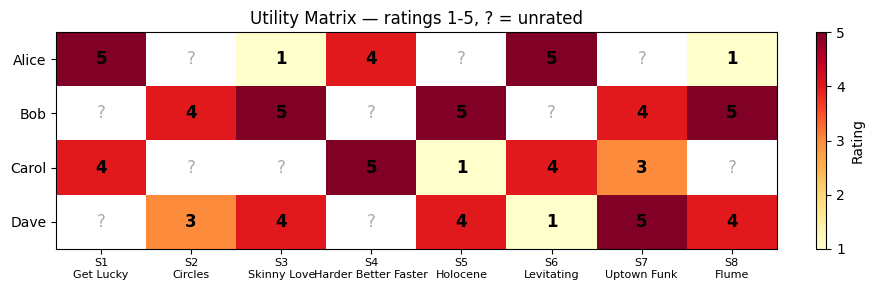

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
mat = U.values.astype(float)
im  = ax.imshow(mat, cmap="YlOrRd", vmin=1, vmax=5, aspect="auto")

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{int(val)}", ha="center", va="center", fontsize=12, fontweight="bold")
        else:
            ax.text(j, i, "?", ha="center", va="center", fontsize=12, color="#aaa")

ax.set_xticks(range(len(song_ids)))
ax.set_xticklabels([f"{sid}\n{songs.loc[songs.id==sid,'name'].values[0]}" for sid in song_ids],
                   fontsize=8)
ax.set_yticks(range(len(U.index)))
ax.set_yticklabels(U.index, fontsize=10)
ax.set_title("Utility Matrix — ratings 1-5, ? = unrated", fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.02, label="Rating")
plt.tight_layout()
plt.show()

---
## 2. Building Item Vectors — Simple to Complex

To compute similarity we need to represent each song as a **numeric vector**.
We will build this representation in three steps, from simplest to most expressive.

### Step A — Boolean: "Did the user like it?"

The crudest representation: 1 if the song was rated ≥ 4 (liked), 0 otherwise.
No audio information — just a binary signal from the utility matrix.

In [5]:
liked = (U >= 4).astype(float)   # 1 = liked, 0 = not liked or unrated

print("Boolean liked matrix  (1 = rated ≥ 4):")
print(liked.to_string())
print()
print("→ Song S1 (Get Lucky) was liked by:",
      ", ".join(liked.index[liked["S1"] == 1]))

Boolean liked matrix  (1 = rated ≥ 4):
        S1   S2   S3   S4   S5   S6   S7   S8
Alice  1.0  0.0  0.0  1.0  0.0  1.0  0.0  0.0
Bob    0.0  1.0  1.0  0.0  1.0  0.0  1.0  1.0
Carol  1.0  0.0  0.0  1.0  0.0  1.0  0.0  0.0
Dave   0.0  0.0  1.0  0.0  1.0  0.0  1.0  1.0

→ Song S1 (Get Lucky) was liked by: Alice, Carol


### Step B — One-Hot: Categorical Features

The **key** (musical key) is categorical. C and D are not "1 apart" in any useful sense.
We encode it as a binary vector with one dimension per possible key.

> "It is easy to do so for features that are sets of discrete values… imagine that there is a component
> for each actor, with 1 if the actor is in the movie, and 0 if not." — Leskovec et al.

In [6]:
all_keys   = sorted(songs["key"].unique())           # ['A', 'C', 'D', 'G']
all_artists = sorted(songs["artists"].unique())      # all unique artists

key_onehot    = pd.get_dummies(songs["key"],    prefix="key")
artist_onehot = pd.get_dummies(songs["artists"], prefix="artist")

print("Key one-hot encoding:")
display_df = pd.concat([songs[["id", "name", "key"]], key_onehot], axis=1)
print(display_df.to_string(index=False))
print()
print("Artist one-hot encoding:")
display_art = pd.concat([songs[["id", "name", "artists"]], artist_onehot], axis=1)
print(display_art.to_string(index=False))
print()
print("→ S1 and S6 both have key=G, so their key vectors are identical.")
print("  Cosine similarity of their key vectors:",
      cosine_similarity(key_onehot.iloc[[0]], key_onehot.iloc[[5]])[0][0])

Key one-hot encoding:
id                 name key  key_A  key_C  key_D  key_G
S1            Get Lucky   G  False  False  False   True
S2              Circles   C  False   True  False  False
S3          Skinny Love   D  False  False   True  False
S4 Harder Better Faster   A   True  False  False  False
S5             Holocene   C  False   True  False  False
S6           Levitating   G  False  False  False   True
S7          Uptown Funk   D  False  False   True  False
S8                Flume   A   True  False  False  False

Artist one-hot encoding:
id                 name     artists  artist_Bon Iver  artist_Daft Punk  artist_Dua Lipa  artist_Mark Ronson  artist_Post Malone
S1            Get Lucky   Daft Punk            False              True            False               False               False
S2              Circles Post Malone            False             False            False               False                True
S3          Skinny Love    Bon Iver             True            

### Step C — Continuous Features (Raw then Standardized)

Audio features like `tempo` (60–200 BPM) and `energy` (0–1) are on very different scales.
If we concatenate them raw, tempo dominates purely because its numbers are bigger.

**Standardization** (zero mean, unit variance) puts all features on equal footing.

In [7]:
AUDIO_COLS = ["tempo", "energy"]

raw_audio = songs[AUDIO_COLS].values.astype(float)
scaler    = StandardScaler()
std_audio = scaler.fit_transform(raw_audio)

print("Raw audio features:")
print(f"  {'Song':<22} {'tempo':>8} {'energy':>8}")
print("  " + "-" * 40)
for i, row in songs.iterrows():
    print(f"  {row['name']:<22} {raw_audio[i,0]:>8.1f} {raw_audio[i,1]:>8.2f}")

print()
print("Standardized audio features (mean=0, std=1):")
print(f"  {'Song':<22} {'tempo_z':>10} {'energy_z':>10}")
print("  " + "-" * 44)
for i, row in songs.iterrows():
    print(f"  {row['name']:<22} {std_audio[i,0]:>10.3f} {std_audio[i,1]:>10.3f}")

print()
print("→ After standardization, tempo and energy contribute equally to distances.")

Raw audio features:
  Song                      tempo   energy
  ----------------------------------------
  Get Lucky                 128.0     0.90
  Circles                    98.0     0.65
  Skinny Love                72.0     0.25
  Harder Better Faster      135.0     0.95
  Holocene                   80.0     0.30
  Levitating                122.0     0.85
  Uptown Funk               105.0     0.60
  Flume                      68.0     0.20

Standardized audio features (mean=0, std=1):
  Song                      tempo_z   energy_z
  --------------------------------------------
  Get Lucky                   1.111      1.097
  Circles                    -0.123      0.219
  Skinny Love                -1.194     -1.185
  Harder Better Faster        1.399      1.273
  Holocene                   -0.864     -1.010
  Levitating                  0.864      0.922
  Uptown Funk                 0.165      0.044
  Flume                      -1.358     -1.361

→ After standardization, tempo an

### Step D — Full Item Profile Vector

Combine all representations: one-hot key + one-hot artist + standardized audio.

Each song is now a single vector we can use for similarity computation.

In [8]:
item_vectors = np.hstack([key_onehot.values,
                          artist_onehot.values,
                          std_audio])

feature_names = (list(key_onehot.columns) +
                 list(artist_onehot.columns) +
                 ["tempo_z", "energy_z"])

print(f"Item vector dimension: {item_vectors.shape[1]}  "
      f"(4 key + {len(all_artists)} artist + 2 audio)")
print()
print(f"  {'Feature':<22}", end="")
for sid in song_ids:
    print(f"{sid:>8}", end="")
print()
print("  " + "-" * (22 + 8 * len(song_ids)))
for j, feat in enumerate(feature_names):
    print(f"  {feat:<22}", end="")
    for i in range(len(songs)):
        print(f"{item_vectors[i, j]:>8.2f}", end="")
    print()

Item vector dimension: 11  (4 key + 5 artist + 2 audio)

  Feature                     S1      S2      S3      S4      S5      S6      S7      S8
  --------------------------------------------------------------------------------------
  key_A                     0.00    0.00    0.00    1.00    0.00    0.00    0.00    1.00
  key_C                     0.00    1.00    0.00    0.00    1.00    0.00    0.00    0.00
  key_D                     0.00    0.00    1.00    0.00    0.00    0.00    1.00    0.00
  key_G                     1.00    0.00    0.00    0.00    0.00    1.00    0.00    0.00
  artist_Bon Iver           0.00    0.00    1.00    0.00    1.00    0.00    0.00    1.00
  artist_Daft Punk          1.00    0.00    0.00    1.00    0.00    0.00    0.00    0.00
  artist_Dua Lipa           0.00    0.00    0.00    0.00    0.00    1.00    0.00    0.00
  artist_Mark Ronson        0.00    0.00    0.00    0.00    0.00    0.00    1.00    0.00
  artist_Post Malone        0.00    1.00    0.00    0

---
## 3. Content-Based Filtering

**Core idea:** a user's taste = average of the item vectors of songs they liked.
Recommend items whose vectors are closest (cosine similarity) to that user vector.

> "With profile vectors for both users and items, we can estimate the degree to which a user would
> prefer an item by computing the cosine distance between the user's and item's vectors."

**Note:** the utility matrix is used only to identify *which songs* the user liked.
Once we have the liked songs, similarity is computed entirely from item content — not from ratings.

### Cosine Similarity — Quick Recap

$$\text{sim}(u, v) = \frac{u \cdot v}{\|u\| \|v\|}$$

- Result in **[−1, 1]**. Higher = more similar.
- Measures **angle** between vectors, not magnitude — so a user who gave all 5s and one who gave all 3s
  can still be "similar" if they like the same features.

In [9]:
# Quick demo: cosine sim between S1 and all other songs
sim_s1 = cosine_similarity(item_vectors[[0]], item_vectors)[0]

print("Cosine similarity: S1 (Get Lucky) vs all songs")
print(f"  {'Song':<24} {'key':>5} {'tempo':>7} {'energy':>8} {'cosine_sim':>12}")
print("  " + "-" * 60)
for i, row in songs.iterrows():
    print(f"  {row['name']:<24} {row['key']:>5} {row['tempo']:>7} "
          f"{row['energy']:>8.2f} {sim_s1[i]:>12.4f}")

print()
print("→ S4 (Harder Better Faster) — same artist, high energy, fast tempo — ranks highest.")
print("→ S3/S5/S8 (Bon Iver) — acoustic, slow — rank lowest.")

Cosine similarity: S1 (Get Lucky) vs all songs
  Song                       key   tempo   energy   cosine_sim
  ------------------------------------------------------------
  Get Lucky                    G     128     0.90       1.0000
  Circles                      C      98     0.65       0.0342
  Skinny Love                  D      72     0.25      -0.5674
  Harder Better Faster         A     135     0.95       0.7942
  Holocene                     C      80     0.30      -0.5059
  Levitating                   G     122     0.85       0.7438
  Uptown Funk                  D     105     0.60       0.0770
  Flume                        A      68     0.20      -0.5971

→ S4 (Harder Better Faster) — same artist, high energy, fast tempo — ranks highest.
→ S3/S5/S8 (Bon Iver) — acoustic, slow — rank lowest.


In [10]:
def build_user_profile(username, utility_matrix, item_vecs, song_ids, threshold=4):
    """Average item vector of songs rated >= threshold."""
    ratings = utility_matrix.loc[username]
    liked_ids = ratings[ratings >= threshold].index.tolist()
    
    if not liked_ids:
        raise ValueError(f"{username} has no liked songs")
    
    liked_indices = [song_ids.index(sid) for sid in liked_ids]
    profile = item_vecs[liked_indices].mean(axis=0)
    return profile, liked_ids


def recommend_content_based(username, utility_matrix, item_vecs, songs_df, song_ids, top_k=3):
    profile, liked_ids = build_user_profile(username, utility_matrix, item_vecs, song_ids)
    
    sims = cosine_similarity(profile.reshape(1, -1), item_vecs)[0]
    
    # Rank, excluding already-liked songs
    ranked = sorted(
        [(i, sims[i]) for i in range(len(songs_df)) if song_ids[i] not in liked_ids],
        key=lambda x: -x[1]
    )
    
    print(f"--- Content-Based Recommendations for {username} ---")
    print(f"Liked songs (rated ≥ 4): {liked_ids}")
    print()
    print(f"  {'#':<4} {'ID':<5} {'Song':<22} {'key':>5} {'tempo':>7} {'energy':>8} {'similarity':>11}")
    print("  " + "-" * 66)
    for rank, (idx, sim) in enumerate(ranked[:top_k], 1):
        row = songs_df.iloc[idx]
        print(f"  {rank:<4} {row['id']:<5} {row['name']:<22} {row['key']:>5} "
              f"{row['tempo']:>7} {row['energy']:>8.2f} {sim:>11.4f}")
    return ranked


_ = recommend_content_based("Alice", U, item_vectors, songs, song_ids)

--- Content-Based Recommendations for Alice ---
Liked songs (rated ≥ 4): ['S1', 'S4', 'S6']

  #    ID    Song                     key   tempo   energy  similarity
  ------------------------------------------------------------------
  1    S7    Uptown Funk                D     105     0.60      0.0866
  2    S2    Circles                    C      98     0.65      0.0375
  3    S5    Holocene                   C      80     0.30     -0.5665


In [11]:
print()
_ = recommend_content_based("Bob", U, item_vectors, songs, song_ids)


--- Content-Based Recommendations for Bob ---
Liked songs (rated ≥ 4): ['S2', 'S3', 'S5', 'S7', 'S8']

  #    ID    Song                     key   tempo   energy  similarity
  ------------------------------------------------------------------
  1    S6    Levitating                 G     122     0.85     -0.4829
  2    S4    Harder Better Faster       A     135     0.95     -0.5156
  3    S1    Get Lucky                  G     128     0.90     -0.5378


### Visualizing User Profiles vs Item Profiles

We reduce to 2D using the two most informative dimensions (tempo_z, energy_z) for interpretability.

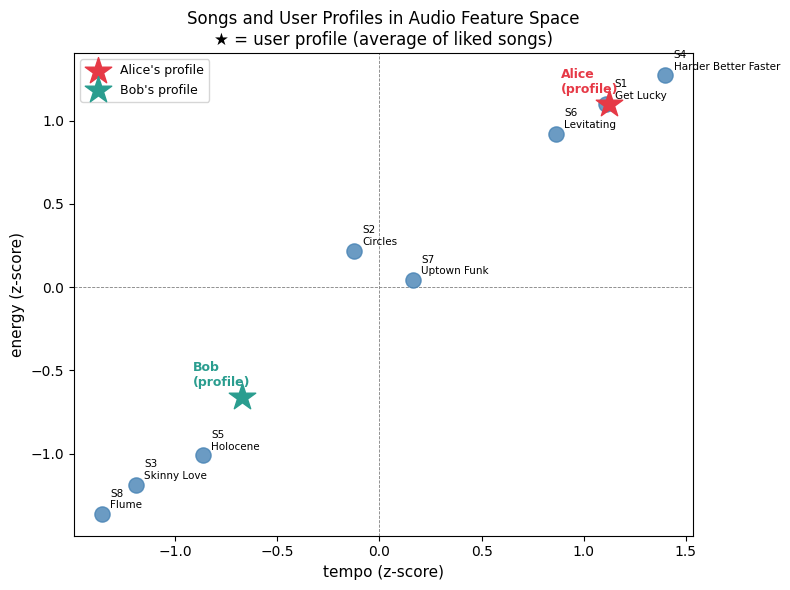

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot all songs
tempo_z  = std_audio[:, 0]
energy_z = std_audio[:, 1]

ax.scatter(tempo_z, energy_z, s=120, color="steelblue", zorder=3, alpha=0.8)
for i, row in songs.iterrows():
    ax.annotate(f"{row['id']}\n{row['name']}", (tempo_z[i], energy_z[i]),
                textcoords="offset points", xytext=(6, 4), fontsize=7.5)

# Plot user profiles for Alice and Bob
user_colors = {"Alice": "#E63946", "Bob": "#2A9D8F"}
for user, color in user_colors.items():
    profile, liked_ids = build_user_profile(user, U, item_vectors, song_ids)
    # profile tempo_z and energy_z are the last 2 dims
    px, py = profile[-2], profile[-1]
    ax.scatter(px, py, s=400, color=color, marker="*", zorder=5, label=f"{user}'s profile")
    ax.annotate(f"{user}\n(profile)", (px, py),
                textcoords="offset points", xytext=(-35, 8),
                fontsize=9, color=color, fontweight="bold")

ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.6, linestyle="--")
ax.set_xlabel("tempo (z-score)", fontsize=11)
ax.set_ylabel("energy (z-score)", fontsize=11)
ax.set_title("Songs and User Profiles in Audio Feature Space\n"
             "★ = user profile (average of liked songs)", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Collaborative Filtering (User-User)

**Core idea:** find users whose rating patterns are similar to mine.
Predict my unrated songs by taking a weighted average of similar users' ratings.

> "Collaborative filtering systems recommend items based on similarity measures between users and/or items.
> The items recommended to a user are those preferred by similar users."

**Key difference from content-based:**
- We never look at song features.
- User vectors are rows of the **utility matrix** (their ratings).
- Similarity = cosine similarity of those rating rows.

### Step 1: Represent Each User as a Ratings Vector

In [13]:
# Fill NaN with 0 for similarity computation (unrated = neutral)
U_filled = U.fillna(0)

print("User vectors (utility matrix rows, NaN filled with 0):")
print(U_filled.to_string())
print()
print("→ Each row is a user's 'taste vector' in 8-dimensional song space.")
print("  Users who rated the same songs similarly will have high cosine similarity.")

User vectors (utility matrix rows, NaN filled with 0):
        S1   S2   S3   S4   S5   S6   S7   S8
Alice  5.0  0.0  1.0  4.0  0.0  5.0  0.0  1.0
Bob    0.0  4.0  5.0  0.0  5.0  0.0  4.0  5.0
Carol  4.0  0.0  0.0  5.0  1.0  4.0  3.0  0.0
Dave   0.0  3.0  4.0  0.0  4.0  1.0  5.0  4.0

→ Each row is a user's 'taste vector' in 8-dimensional song space.
  Users who rated the same songs similarly will have high cosine similarity.


### Step 2: Compute User-User Similarity

In [14]:
user_vecs    = U_filled.values.astype(float)   # (4, 8)
user_sim_mat = cosine_similarity(user_vecs)     # (4, 4)
user_names   = U.index.tolist()

sim_df = pd.DataFrame(user_sim_mat, index=user_names, columns=user_names)

print("User-User Cosine Similarity Matrix:")
print(sim_df.round(3).to_string())
print()
print("Interpretation:")
for u in user_names:
    most_similar = sim_df[u].drop(u).idxmax()
    sim_val      = sim_df.loc[u, most_similar]
    print(f"  {u:<8}  →  most similar to  {most_similar}  (sim={sim_val:.3f})")

User-User Cosine Similarity Matrix:
       Alice    Bob  Carol   Dave
Alice  1.000  0.117  0.889  0.173
Bob    0.117  1.000  0.201  0.976
Carol  0.889  0.201  1.000  0.308
Dave   0.173  0.976  0.308  1.000

Interpretation:
  Alice     →  most similar to  Carol  (sim=0.889)
  Bob       →  most similar to  Dave  (sim=0.976)
  Carol     →  most similar to  Alice  (sim=0.889)
  Dave      →  most similar to  Bob  (sim=0.976)


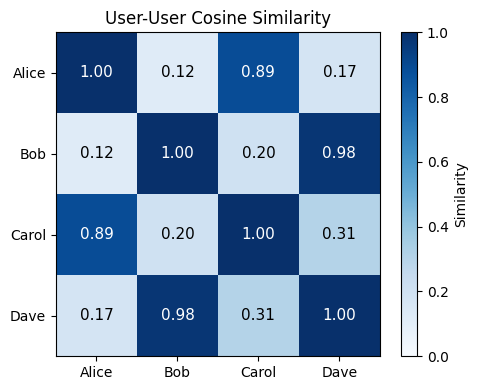

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(user_sim_mat, cmap="Blues", vmin=0, vmax=1)

for i in range(len(user_names)):
    for j in range(len(user_names)):
        ax.text(j, i, f"{user_sim_mat[i,j]:.2f}", ha="center", va="center",
                fontsize=11, color="white" if user_sim_mat[i,j] > 0.6 else "black")

ax.set_xticks(range(len(user_names)))
ax.set_yticks(range(len(user_names)))
ax.set_xticklabels(user_names, fontsize=10)
ax.set_yticklabels(user_names, fontsize=10)
ax.set_title("User-User Cosine Similarity", fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.04, label="Similarity")
plt.tight_layout()
plt.show()

### Step 3: Predict Ratings for Unrated Songs

For target user $u$ and unrated song $s$:

$$\hat{r}_{u,s} = \frac{\sum_{v \in N(u)} \text{sim}(u,v) \cdot r_{v,s}}{\sum_{v \in N(u)} |\text{sim}(u,v)|}$$

Where $N(u)$ = the $k$ most similar users who have rated $s$.

In [16]:
def predict_rating_cf(target_user, song_id, utility_matrix, sim_matrix, user_names, k=2):
    """
    Predict rating for target_user on song_id using k nearest neighbors.
    Returns (predicted_rating, neighbors_used).
    """
    u_idx = user_names.index(target_user)
    
    # Find neighbors who rated this song
    neighbors = []
    for v, vname in enumerate(user_names):
        if vname == target_user:
            continue
        rating = utility_matrix.loc[vname, song_id]
        if not np.isnan(rating):
            neighbors.append((vname, sim_matrix[u_idx, v], rating))
    
    # Sort by similarity, take top-k
    neighbors.sort(key=lambda x: -x[1])
    neighbors = neighbors[:k]
    
    if not neighbors:
        return None, []
    
    num   = sum(sim * r for _, sim, r in neighbors)
    denom = sum(abs(sim) for _, sim, _ in neighbors)
    predicted = num / denom if denom > 0 else None
    return predicted, neighbors


# Walk through Alice's unrated songs step by step
target = "Alice"
alice_unrated = U.loc[target][U.loc[target].isna()].index.tolist()

print(f"--- Collaborative Filtering: predicting ratings for {target} ---")
print(f"Unrated songs: {alice_unrated}")
print()

predictions = {}
for sid in alice_unrated:
    pred, neighbors = predict_rating_cf(target, sid, U, user_sim_mat, user_names, k=2)
    song_name = songs.loc[songs.id == sid, "name"].values[0]
    predictions[sid] = pred
    
    print(f"Song {sid}: {song_name}")
    if neighbors:
        for vname, sim, rating in neighbors:
            print(f"   Neighbor {vname:<8}  sim={sim:.3f}  rated={rating:.0f}")
        print(f"   → Predicted rating for {target}: {pred:.2f}")
    else:
        print(f"   → No neighbors rated this song. Cannot predict.")
    print()

--- Collaborative Filtering: predicting ratings for Alice ---
Unrated songs: ['S2', 'S5', 'S7']

Song S2: Circles
   Neighbor Dave      sim=0.173  rated=3
   Neighbor Bob       sim=0.117  rated=4
   → Predicted rating for Alice: 3.40

Song S5: Holocene
   Neighbor Carol     sim=0.889  rated=1
   Neighbor Dave      sim=0.173  rated=4
   → Predicted rating for Alice: 1.49

Song S7: Uptown Funk
   Neighbor Carol     sim=0.889  rated=3
   Neighbor Dave      sim=0.173  rated=5
   → Predicted rating for Alice: 3.33



In [17]:
# Recommend top-k unrated songs by predicted rating
valid_preds = {sid: pred for sid, pred in predictions.items() if pred is not None}
top_recs    = sorted(valid_preds.items(), key=lambda x: -x[1])

print(f"Final CF recommendations for {target} (ranked by predicted rating):")
print(f"  {'#':<4} {'ID':<5} {'Song':<22} {'Predicted Rating':>18}")
print("  " + "-" * 52)
for rank, (sid, pred) in enumerate(top_recs, 1):
    song_name = songs.loc[songs.id == sid, "name"].values[0]
    print(f"  {rank:<4} {sid:<5} {song_name:<22} {pred:>18.2f}")

Final CF recommendations for Alice (ranked by predicted rating):
  #    ID    Song                     Predicted Rating
  ----------------------------------------------------
  1    S2    Circles                              3.40
  2    S7    Uptown Funk                          3.33
  3    S5    Holocene                             1.49


### Content-Based vs Collaborative Filtering — Side-by-Side

Let's compare what each approach recommends for Alice.

In [18]:
cb_ranked = recommend_content_based("Alice", U, item_vectors, songs, song_ids, top_k=3)
print()

print("--- Collaborative Filtering (top predictions) ---")
for rank, (sid, pred) in enumerate(top_recs[:3], 1):
    song_name = songs.loc[songs.id == sid, "name"].values[0]
    print(f"  {rank}. {sid} {song_name}  (predicted rating: {pred:.2f})")

print()
print("Key difference:")
print("  Content-based looks at song features (tempo, energy, key).")
print("  Collaborative filtering looks at what similar users (Carol) rated.")
print("  CF can surface songs with no audio similarity to Alice's history.")

--- Content-Based Recommendations for Alice ---
Liked songs (rated ≥ 4): ['S1', 'S4', 'S6']

  #    ID    Song                     key   tempo   energy  similarity
  ------------------------------------------------------------------
  1    S7    Uptown Funk                D     105     0.60      0.0866
  2    S2    Circles                    C      98     0.65      0.0375
  3    S5    Holocene                   C      80     0.30     -0.5665

--- Collaborative Filtering (top predictions) ---
  1. S2 Circles  (predicted rating: 3.40)
  2. S7 Uptown Funk  (predicted rating: 3.33)
  3. S5 Holocene  (predicted rating: 1.49)

Key difference:
  Content-based looks at song features (tempo, energy, key).
  Collaborative filtering looks at what similar users (Carol) rated.
  CF can surface songs with no audio similarity to Alice's history.


---
### Predicting All Utility Matrix Entries

To produce a ranked recommendation list we must estimate **every blank cell** in a user's row.
Two dual approaches:

**User-User (normalized)**  
Find $n$ most similar users; for each unrated item $I$:

$$\hat{r}_{U,I} = \bar{r}_U + \frac{\sum_{V \in N(U)} \mathrm{sim}(U,V)\,(r_{V,I} - \bar{r}_V)}{\sum_{V \in N(U)} |\mathrm{sim}(U,V)|}$$

$\bar{r}_V$ is subtracted before averaging so that a neighbor who always rates 5★ doesn't inflate estimates. $\bar{r}_U$ is added back to anchor the prediction on $U$'s own scale.

**Item-Item (normalized)**  
Find $m$ items most similar to $I$ among items $U$ has rated; average $U$'s normalized ratings for those:

$$\hat{r}_{U,I} = \bar{r}_I + \frac{\sum_{J \in N(I)} \mathrm{sim}(I,J)\,(r_{U,J} - \bar{r}_J)}{\sum_{J \in N(I)} |\mathrm{sim}(I,J)|}$$

$\bar{r}_J$ is the mean rating *item* $J$ received across all users.

**Tradeoff:** user-user can surface serendipitous finds; item-item is faster to update (only the new item's column changes when a user adds a rating) and tends to be more accurate when the item catalog is stable.

In [19]:
# ── Normalized User-User prediction ──────────────────────────────────────────

def predict_uu_normalized(target_user, song_id, U, sim_matrix, user_names, k=2):
    """
    Normalized user-user CF.
    Returns (prediction, list of (neighbor_name, sim, raw_rating, neighbor_mean)).
    """
    u_idx       = user_names.index(target_user)
    target_mean = U.loc[target_user].dropna().mean()

    neighbors = []
    for v, vname in enumerate(user_names):
        if vname == target_user:
            continue
        r = U.loc[vname, song_id]
        if not np.isnan(r):
            v_mean = U.loc[vname].dropna().mean()
            neighbors.append((vname, sim_matrix[u_idx, v], r, v_mean))

    neighbors.sort(key=lambda x: -x[1])
    neighbors = neighbors[:k]

    if not neighbors:
        return None, []

    num   = sum(s * (r - vm) for _, s, r, vm in neighbors)
    denom = sum(abs(s) for _, s, _, _ in neighbors)
    pred  = target_mean + num / denom if denom > 0 else target_mean
    return pred, neighbors


# Step-by-step walkthrough: Alice predicting S2 (Circles)
target, target_song = "Alice", "S2"
target_mean = U.loc[target].dropna().mean()
song_name   = songs.loc[songs.id == target_song, "name"].values[0]

print(f"Normalized User-User: predicting {target}'s rating for {target_song} ({song_name})")
print(f"  {target}'s mean rating over rated songs: {target_mean:.2f}")
print()
print(f"  {'Neighbor':<8} {'rated':>7} {'mean':>7} {'normalized':>12} {'sim(U,V)':>10} {'contribution':>14}")
print("  " + "-" * 63)

for vname, sim, r, vm in [
    (vname, sim, r, vm)
    for vname, sim, r, vm in [
        (v, user_sim_mat[user_names.index(target), i], U.loc[v, target_song], U.loc[v].dropna().mean())
        for i, v in enumerate(user_names) if v != target and not np.isnan(U.loc[v, target_song])
    ]
]:
    norm_r = r - vm
    print(f"  {vname:<8} {r:>7.0f} {vm:>7.2f} {norm_r:>+12.2f} {sim:>10.3f} {sim * norm_r:>+14.3f}")

pred_norm, nbrs = predict_uu_normalized(target, target_song, U, user_sim_mat, user_names, k=2)
pred_raw,  _    = predict_rating_cf(target, target_song, U, user_sim_mat, user_names, k=2)

print()
print(f"  Raw prediction (un-normalized):         {pred_raw:.2f}")
print(f"  Normalized prediction:  {target_mean:.2f} (Alice mean)")
for _, s, r, vm in nbrs:
    print(f"    + [{s:.3f} × ({r:.0f} − {vm:.2f})] / Σ|sim|")
print(f"  = {pred_norm:.2f}")

Normalized User-User: predicting Alice's rating for S2 (Circles)
  Alice's mean rating over rated songs: 3.20

  Neighbor   rated    mean   normalized   sim(U,V)   contribution
  ---------------------------------------------------------------
  Bob            4    4.60        -0.60      0.117         -0.070
  Dave           3    3.50        -0.50      0.173         -0.087

  Raw prediction (un-normalized):         3.40
  Normalized prediction:  3.20 (Alice mean)
    + [0.173 × (3 − 3.50)] / Σ|sim|
    + [0.117 × (4 − 4.60)] / Σ|sim|
  = 2.66


In [20]:
# ── Item-Item CF ─────────────────────────────────────────────────────────────

# Item vectors = columns of utility matrix (each item rated by some users)
item_rating_vecs = U.fillna(0).T.values.astype(float)   # (8 items, 4 users)
item_sim_mat     = cosine_similarity(item_rating_vecs)   # (8, 8)

item_sim_df = pd.DataFrame(item_sim_mat, index=song_ids, columns=song_ids)
print("Item-Item Cosine Similarity Matrix (from utility matrix columns):")
print(item_sim_df.round(3).to_string())
print()


def predict_ii_normalized(target_user, song_id, U, item_sim_matrix, song_ids, m=3):
    """
    Normalized item-item CF.
    Normalize by item mean (avg rating that item received across all users).
    Returns (prediction, list of (neighbor_sid, sim, user_rating, item_mean)).
    """
    s_idx    = song_ids.index(song_id)
    item_mean = U[song_id].dropna().mean()   # mean rating item I received

    user_rated = U.loc[target_user].dropna()

    neighbors = []
    for j, sid in enumerate(song_ids):
        if sid == song_id or sid not in user_rated.index:
            continue
        j_mean = U[sid].dropna().mean()
        neighbors.append((sid, item_sim_matrix[s_idx, j], user_rated[sid], j_mean))

    neighbors.sort(key=lambda x: -x[1])
    neighbors = neighbors[:m]

    if not neighbors:
        return None, []

    num   = sum(s * (r - jm) for _, s, r, jm in neighbors)
    denom = sum(abs(s) for _, s, _, _ in neighbors)
    pred  = item_mean + num / denom if denom > 0 else item_mean
    return pred, neighbors


# Step-by-step: Alice predicting S2 (Circles) via item-item
print(f"Normalized Item-Item: predicting Alice's rating for S2 (Circles)")
item_mean_s2 = U["S2"].dropna().mean()
print(f"  S2's mean rating across users who rated it: {item_mean_s2:.2f}")
print()
print(f"  {'Similar item':<22} {'sim(S2,J)':>10} {'Alice rated J':>14} {'J mean':>8} {'normalized':>12}")
print("  " + "-" * 70)

user_rated_alice = U.loc["Alice"].dropna()
for j, sid in enumerate(song_ids):
    if sid == "S2" or sid not in user_rated_alice.index:
        continue
    s    = item_sim_mat[song_ids.index("S2"), j]
    r    = user_rated_alice[sid]
    jm   = U[sid].dropna().mean()
    sname = songs.loc[songs.id == sid, "name"].values[0]
    print(f"  {sid} {sname:<18} {s:>10.3f} {r:>14.0f} {jm:>8.2f} {r-jm:>+12.2f}")

pred_ii, ii_nbrs = predict_ii_normalized("Alice", "S2", U, item_sim_mat, song_ids, m=3)
print()
print(f"  Item-Item normalized prediction: {pred_ii:.2f}")

Item-Item Cosine Similarity Matrix (from utility matrix columns):
       S1     S2     S3     S4     S5     S6     S7     S8
S1  1.000  0.000  0.120  0.976  0.096  0.988  0.265  0.120
S2  0.000  1.000  0.988  0.000  0.988  0.093  0.877  0.988
S3  0.120  0.988  1.000  0.096  0.976  0.214  0.873  1.000
S4  0.976  0.000  0.096  1.000  0.120  0.964  0.331  0.096
S5  0.096  0.988  0.976  0.120  1.000  0.190  0.938  0.976
S6  0.988  0.093  0.214  0.964  0.190  1.000  0.371  0.214
S7  0.265  0.877  0.873  0.331  0.938  0.371  1.000  0.873
S8  0.120  0.988  1.000  0.096  0.976  0.214  0.873  1.000

Normalized Item-Item: predicting Alice's rating for S2 (Circles)
  S2's mean rating across users who rated it: 3.50

  Similar item            sim(S2,J)  Alice rated J   J mean   normalized
  ----------------------------------------------------------------------
  S1 Get Lucky               0.000              5     4.50        +0.50
  S3 Skinny Love             0.988              1     3.33        -

Original utility matrix  (? = unrated):
        S1   S2   S3   S4   S5   S6   S7   S8
Alice  5.0  NaN  1.0  4.0  NaN  5.0  NaN  1.0
Bob    NaN  4.0  5.0  NaN  5.0  NaN  4.0  5.0
Carol  4.0  NaN  NaN  5.0  1.0  4.0  3.0  NaN
Dave   NaN  3.0  4.0  NaN  4.0  1.0  5.0  4.0

Filled — User-User normalized (predicted cells marked *):
          S1     S2     S3     S4     S5     S6     S7     S8
Alice    5.0  2.66*    1.0    4.0  1.27*    5.0  3.11*    1.0
Bob    5.64*    4.0    5.0  5.91*    5.0  2.63*    4.0    5.0
Carol    4.0  2.86*  1.90*    5.0    1.0    4.0    3.0  1.90*
Dave   4.53*    3.0    4.0  4.81*    4.0    1.0    5.0    4.0

Filled — Item-Item normalized (predicted cells marked *):
          S1     S2     S3     S4     S5     S6     S7     S8
Alice    5.0  1.35*    1.0    4.0  1.36*    5.0  2.37*    1.0
Bob    5.29*    4.0    5.0  5.16*    5.0  4.23*    4.0    5.0
Carol    4.0  1.91*  1.88*    5.0    1.0    4.0    3.0  1.88*
Dave   3.07*    3.0    4.0  3.20*    4.0    1.0    5.0

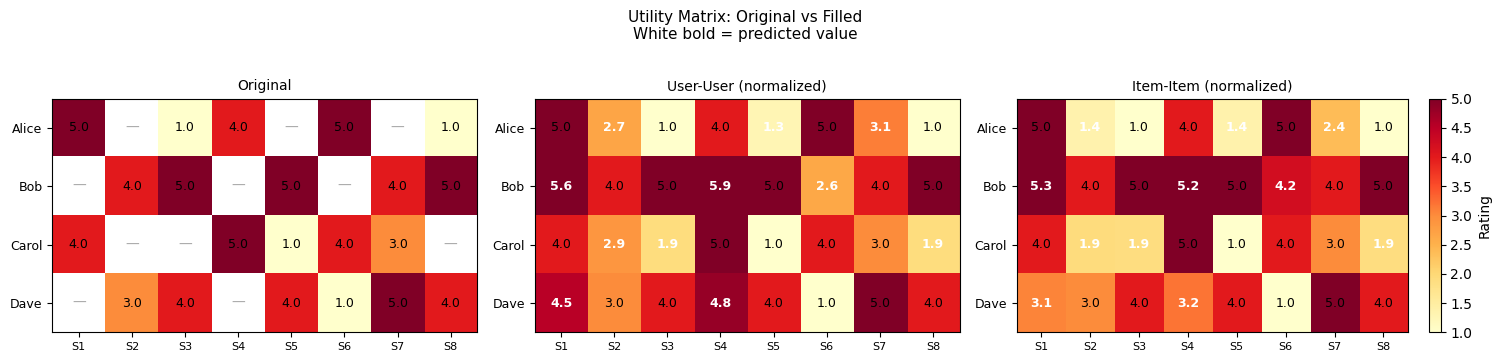

In [21]:
# ── Full matrix reconstruction: fill every NaN with both approaches ───────────

U_uu = U.copy().astype(float)   # user-user normalized predictions
U_ii = U.copy().astype(float)   # item-item normalized predictions

for u in user_names:
    for sid in song_ids:
        if np.isnan(U.loc[u, sid]):
            p_uu, _ = predict_uu_normalized(u, sid, U, user_sim_mat, user_names, k=2)
            p_ii, _ = predict_ii_normalized(u, sid, U, item_sim_mat, song_ids, m=3)
            U_uu.loc[u, sid] = round(p_uu, 2) if p_uu is not None else np.nan
            U_ii.loc[u, sid] = round(p_ii, 2) if p_ii is not None else np.nan

print("Original utility matrix  (? = unrated):")
print(U.to_string())
print()
print("Filled — User-User normalized (predicted cells marked *):")
display_uu = U.copy().astype(object)
for u in user_names:
    for sid in song_ids:
        if np.isnan(U.loc[u, sid]):
            v = U_uu.loc[u, sid]
            display_uu.loc[u, sid] = f"{v:.2f}*" if not np.isnan(v) else "—"
print(display_uu.to_string())
print()
print("Filled — Item-Item normalized (predicted cells marked *):")
display_ii = U.copy().astype(object)
for u in user_names:
    for sid in song_ids:
        if np.isnan(U.loc[u, sid]):
            v = U_ii.loc[u, sid]
            display_ii.loc[u, sid] = f"{v:.2f}*" if not np.isnan(v) else "—"
print(display_ii.to_string())

# ── Visualize both filled matrices side by side ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

labels = ["Original", "User-User (normalized)", "Item-Item (normalized)"]
mats   = [U.values.astype(float), U_uu.values.astype(float), U_ii.values.astype(float)]

for ax, mat, title in zip(axes, mats, labels):
    im = ax.imshow(mat, cmap="YlOrRd", vmin=1, vmax=5, aspect="auto")
    original_mat = U.values.astype(float)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            was_nan = np.isnan(original_mat[i, j])
            if np.isnan(val):
                ax.text(j, i, "—", ha="center", va="center", fontsize=10, color="#aaa")
            else:
                color  = "white" if was_nan else "black"
                weight = "bold" if was_nan else "normal"
                ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                        fontsize=9, color=color, fontweight=weight)
    ax.set_xticks(range(len(song_ids)))
    ax.set_xticklabels(song_ids, fontsize=8)
    ax.set_yticks(range(len(user_names)))
    ax.set_yticklabels(user_names, fontsize=9)
    ax.set_title(title, fontsize=10)

plt.colorbar(im, ax=axes[-1], fraction=0.03, label="Rating")
plt.suptitle("Utility Matrix: Original vs Filled\n"
             "White bold = predicted value", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. How the Choice of Distance Metric Shapes User Similarity

Before recommending anything, we need to decide: *how do we measure whether two users are similar?*
The same utility matrix produces very different similarity scores — and very different neighbour rankings —
depending on which metric we pick.

We compare four approaches:

| Metric | User vector | What it captures |
|---|---|---|
| **Cosine (raw)** | Fill NaN → 0, use raw 1–5 ratings | Alignment of absolute rating magnitudes |
| **Jaccard** | Set of *liked* items (rated ≥ 4) | Overlap in taste regardless of rating intensity |
| **Cosine (binary)** | 1 if liked, 0 otherwise | Alignment of liked/disliked patterns, ignoring rating strength |
| **Cosine (mean-centered)** | Subtract each user's mean; NaN → 0 | Relative preferences — corrects for generous/strict raters |

In [22]:
from sklearn.manifold import MDS

# ── Utility matrix recap ─────────────────────────────────────────────────────
print("Utility matrix (NaN = unrated):")
print(U.to_string())
print()

# ── Case 1: Cosine on raw ratings (NaN → 0) ──────────────────────────────────
U_raw = U.fillna(0).values.astype(float)
sim_cosine_raw = cosine_similarity(U_raw)

# ── Case 2: Jaccard (liked set = rated ≥ 4) ──────────────────────────────────
LIKE_THRESHOLD = 4
liked_sets = {u: set(U.loc[u][U.loc[u] >= LIKE_THRESHOLD].index) for u in user_names}

sim_jaccard = np.zeros((len(user_names), len(user_names)))
for i, u in enumerate(user_names):
    for j, v in enumerate(user_names):
        inter = len(liked_sets[u] & liked_sets[v])
        union = len(liked_sets[u] | liked_sets[v])
        sim_jaccard[i, j] = inter / union if union > 0 else 0.0

# ── Case 3: Cosine on binary (liked=1, else=0) ───────────────────────────────
U_binary = (U.fillna(0) >= LIKE_THRESHOLD).astype(float).values
sim_cosine_binary = cosine_similarity(U_binary)

# ── Case 4: Cosine on mean-centered ratings (NaN → 0 after centering) ────────
U_mc = U.copy()
for u in user_names:
    rated_vals = U.loc[u].dropna()
    if len(rated_vals) > 0:
        U_mc.loc[u] = U.loc[u] - rated_vals.mean()
U_mc_filled = U_mc.fillna(0).values.astype(float)
sim_cosine_mc = cosine_similarity(U_mc_filled)

# ── Print all four matrices ───────────────────────────────────────────────────
cases = [
    ("Cosine (raw ratings)",    sim_cosine_raw),
    ("Jaccard (liked sets)",    sim_jaccard),
    ("Cosine (binary)",         sim_cosine_binary),
    ("Cosine (mean-centered)",  sim_cosine_mc),
]

for label, mat in cases:
    df_sim = pd.DataFrame(mat, index=user_names, columns=user_names)
    print(f"\n── {label} ──")
    print(df_sim.round(3).to_string())
    # Most similar neighbour per user
    for u in user_names:
        nn   = df_sim[u].drop(u).idxmax()
        val  = df_sim.loc[u, nn]
        print(f"   {u} ↔ {nn}: {val:.3f}")

Utility matrix (NaN = unrated):
        S1   S2   S3   S4   S5   S6   S7   S8
Alice  5.0  NaN  1.0  4.0  NaN  5.0  NaN  1.0
Bob    NaN  4.0  5.0  NaN  5.0  NaN  4.0  5.0
Carol  4.0  NaN  NaN  5.0  1.0  4.0  3.0  NaN
Dave   NaN  3.0  4.0  NaN  4.0  1.0  5.0  4.0


── Cosine (raw ratings) ──
       Alice    Bob  Carol   Dave
Alice  1.000  0.117  0.889  0.173
Bob    0.117  1.000  0.201  0.976
Carol  0.889  0.201  1.000  0.308
Dave   0.173  0.976  0.308  1.000
   Alice ↔ Carol: 0.889
   Bob ↔ Dave: 0.976
   Carol ↔ Alice: 0.889
   Dave ↔ Bob: 0.976

── Jaccard (liked sets) ──
       Alice  Bob  Carol  Dave
Alice    1.0  0.0    1.0   0.0
Bob      0.0  1.0    0.0   0.8
Carol    1.0  0.0    1.0   0.0
Dave     0.0  0.8    0.0   1.0
   Alice ↔ Carol: 1.000
   Bob ↔ Dave: 0.800
   Carol ↔ Alice: 1.000
   Dave ↔ Bob: 0.800

── Cosine (binary) ──
       Alice    Bob  Carol   Dave
Alice    1.0  0.000    1.0  0.000
Bob      0.0  1.000    0.0  0.894
Carol    1.0  0.000    1.0  0.000
Dave     0.0  0.8

### User Profile Centroids in Song Feature Space

We can further visualize this in the song feature space (tempo × energy) by looking at each user's taste centroid under different metrics

Each metric implies a different definition of which songs "represent" a user:

| Metric | Songs included in centroid | Weight |
|---|---|---|
| **Cosine (raw)** | All rated songs (liked *and* disliked) | Rating value (1–5) |
| **Jaccard / Binary** | Only songs rated ≥ 4 | Equal |
| **Mean-centered** | Songs rated **above the user's own mean** | Equal — threshold shifts per user |

Key insight: because Bob's mean is 4.6, songs he rated 4 (Circles, Uptown Funk) fall *below* his mean under the mean-centered definition — they drop out of his centroid, pulling it toward his truly top-rated songs (Skinny Love, Holocene, Flume).

In [23]:
def song_space_centroids(metric_name, U, song_ids, user_names, std_audio):
    """
    For each user, compute a profile centroid in (tempo_z, energy_z) under metric_name.
    Returns:
      centroids : dict  user → np.array([cx, cy])
      used_sids : dict  user → list of song IDs that contributed
    """
    centroids, used_sids = {}, {}
    for u in user_names:
        rated = U.loc[u].dropna()

        if metric_name == "raw":
            # Rating-weighted average of all rated songs
            sids    = rated.index.tolist()
            idxs    = [song_ids.index(s) for s in sids]
            centroid = np.average(std_audio[idxs], axis=0, weights=rated.values)

        elif metric_name in ("jaccard", "binary"):
            sids    = rated[rated >= LIKE_THRESHOLD].index.tolist()
            idxs    = [song_ids.index(s) for s in sids]
            centroid = std_audio[idxs].mean(axis=0) if sids else np.zeros(2)

        elif metric_name == "mc":
            mean_r  = rated.mean()
            sids    = rated[rated > mean_r].index.tolist()
            idxs    = [song_ids.index(s) for s in sids]
            centroid = std_audio[idxs].mean(axis=0) if sids else np.zeros(2)

        centroids[u] = centroid
        used_sids[u] = sids

    return centroids, used_sids


METRIC_SPACE_CASES = [
    ("raw",    "Cosine (raw)\nRating-weighted avg\nof all rated songs"),
    ("jaccard","Jaccard / Binary\nAvg of liked songs\n(rated ≥ 4)"),
    ("binary", "Cosine (binary)\nAvg of liked songs\n(rated ≥ 4)"),
    ("mc",     "Mean-Centered\nAvg of songs rated\nabove user's mean"),
]

print("Profile centroids in song space (tempo_z, energy_z):")
print()
for metric_name, label in METRIC_SPACE_CASES:
    centroids, used_sids = song_space_centroids(metric_name, U, song_ids, user_names, std_audio)
    print(f"  [{label.replace(chr(10), ' | ')}]")
    for u in user_names:
        cx, cy = centroids[u]
        print(f"    {u:<8}  contributing songs={used_sids[u]}  centroid=({cx:+.2f}, {cy:+.2f})")
    print()

print("Note: Jaccard and Binary share the same liked-set definition (≥4),")
print("      so their centroids are identical in song space.")

Profile centroids in song space (tempo_z, energy_z):

  [Cosine (raw) | Rating-weighted avg | of all rated songs]
    Alice     contributing songs=['S1', 'S3', 'S4', 'S6', 'S8']  centroid=(+0.81, +0.79)
    Bob       contributing songs=['S2', 'S3', 'S5', 'S7', 'S8']  centroid=(-0.74, -0.73)
    Carol     contributing songs=['S1', 'S4', 'S5', 'S6', 'S7']  centroid=(+0.85, +0.80)
    Dave      contributing songs=['S2', 'S3', 'S5', 'S6', 'S7', 'S8']  centroid=(-0.59, -0.59)

  [Jaccard / Binary | Avg of liked songs | (rated ≥ 4)]
    Alice     contributing songs=['S1', 'S4', 'S6']  centroid=(+1.13, +1.10)
    Bob       contributing songs=['S2', 'S3', 'S5', 'S7', 'S8']  centroid=(-0.68, -0.66)
    Carol     contributing songs=['S1', 'S4', 'S6']  centroid=(+1.13, +1.10)
    Dave      contributing songs=['S3', 'S5', 'S7', 'S8']  centroid=(-0.81, -0.88)

  [Cosine (binary) | Avg of liked songs | (rated ≥ 4)]
    Alice     contributing songs=['S1', 'S4', 'S6']  centroid=(+1.13, +1.10)
    Bob 

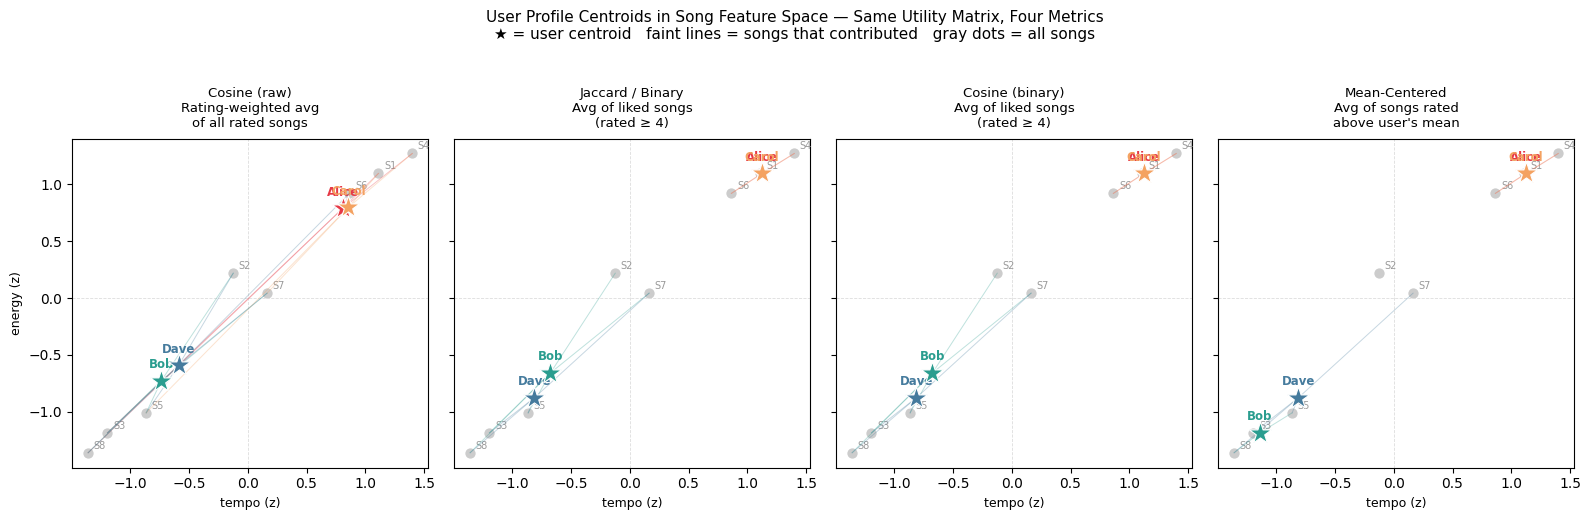


What to notice:
  • Cosine (raw): disliked songs (rated 1-2) are included with their weights,
    pulling some centroids toward the low-energy corner.
  • Jaccard/Binary: centroids shift toward the songs each user genuinely liked.
  • Mean-centered: Bob's centroid moves significantly — Circles & Uptown Funk
    (rated 4, below his 4.6 mean) drop out, pulling him into the slow/acoustic region.


In [24]:
USER_COLORS = ["#E63946", "#2A9D8F", "#F4A261", "#457B9D"]
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

tempo_z  = std_audio[:, 0]
energy_z = std_audio[:, 1]

for ax, (metric_name, title) in zip(axes, METRIC_SPACE_CASES):
    centroids, used_sids = song_space_centroids(metric_name, U, song_ids, user_names, std_audio)

    # All songs as gray backdrop
    ax.scatter(tempo_z, energy_z, s=55, color="#cccccc", zorder=2, linewidths=0)
    for i, row in songs.iterrows():
        ax.annotate(f"{row['id']}", (tempo_z[i], energy_z[i]),
                    textcoords="offset points", xytext=(4, 3),
                    fontsize=7, color="#999")

    # User centroids
    for u, color in zip(user_names, USER_COLORS):
        cx, cy = centroids[u]

        # Faint lines from centroid to each contributing song
        for sid in used_sids[u]:
            si = song_ids.index(sid)
            ax.plot([cx, tempo_z[si]], [cy, energy_z[si]],
                    color=color, linewidth=0.7, alpha=0.3, zorder=3)

        ax.scatter(cx, cy, s=280, marker="*", color=color, zorder=5,
                   edgecolors="white", linewidth=0.8)
        ax.annotate(u, (cx, cy), textcoords="offset points",
                    xytext=(0, 9), ha="center", fontsize=8.5,
                    color=color, fontweight="bold")

    ax.axhline(0, color="#ddd", linewidth=0.6, linestyle="--")
    ax.axvline(0, color="#ddd", linewidth=0.6, linestyle="--")
    ax.set_title(title, fontsize=9.5, pad=8)
    ax.set_xlabel("tempo (z)", fontsize=9)

axes[0].set_ylabel("energy (z)", fontsize=9)

plt.suptitle(
    "User Profile Centroids in Song Feature Space — Same Utility Matrix, Four Metrics\n"
    "★ = user centroid   faint lines = songs that contributed   gray dots = all songs",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.show()

print()
print("What to notice:")
print("  • Cosine (raw): disliked songs (rated 1-2) are included with their weights,")
print("    pulling some centroids toward the low-energy corner.")
print("  • Jaccard/Binary: centroids shift toward the songs each user genuinely liked.")
print("  • Mean-centered: Bob's centroid moves significantly — Circles & Uptown Funk")
print("    (rated 4, below his 4.6 mean) drop out, pulling him into the slow/acoustic region.")

---
## 6. Pitfalls

Recommendation systems are sensitive to how vectors are constructed.
Three important failure modes to know:

### Pitfall 1 — Feature Scaling Dominates Similarity

If we concatenate `[tempo, energy]` without standardizing, tempo (60–200) swamps energy (0–1).
Multiplying by $\alpha$ changes how much that dimension contributes to cosine similarity.

> The scaling of $\alpha$ for a continuous component $\alpha \cdot x$ directly changes the geometry
> of the feature space and therefore changes which items are "nearest".

In [25]:
def make_vectors_with_alpha(songs_df, alpha_tempo, alpha_energy):
    t = songs_df["tempo"].values.astype(float)  * alpha_tempo
    e = songs_df["energy"].values.astype(float) * alpha_energy
    return np.column_stack([t, e])


target_song = 0  # S1 Get Lucky

configs = [
    ("Raw (no scaling)",       1.0,   1.0),
    ("Tempo × 0.01",           0.01,  1.0),
    ("Energy × 100",           1.0,  100.0),
    ("Both standardized",      None,  None),   # sentinel → use StandardScaler
]

print("How feature scaling changes top-2 nearest songs to S1 (Get Lucky):")
print()

for label, at, ae in configs:
    if at is None:
        vecs = scaler.fit_transform(songs[["tempo", "energy"]].values.astype(float))
    else:
        vecs = make_vectors_with_alpha(songs, at, ae)
    
    sims   = cosine_similarity(vecs[[target_song]], vecs)[0]
    ranked = sorted([(i, sims[i]) for i in range(len(songs)) if i != target_song], key=lambda x: -x[1])
    top2   = [(songs.iloc[i]["id"], songs.iloc[i]["name"], s) for i, s in ranked[:2]]
    
    print(f"  [{label}]")
    for sid, sname, sim in top2:
        print(f"    {sid} {sname:<24}  sim={sim:.4f}")
    print()

print("→ Same songs, different recommended neighbors, just by changing scale.")
print("  Standardization (last config) is the safest default.")

How feature scaling changes top-2 nearest songs to S1 (Get Lucky):

  [Raw (no scaling)]
    S4 Harder Better Faster      sim=1.0000
    S6 Levitating                sim=1.0000

  [Tempo × 0.01]
    S4 Harder Better Faster      sim=1.0000
    S6 Levitating                sim=1.0000

  [Energy × 100]
    S4 Harder Better Faster      sim=1.0000
    S6 Levitating                sim=1.0000

  [Both standardized]
    S6 Levitating                sim=0.9993
    S4 Harder Better Faster      sim=0.9992

→ Same songs, different recommended neighbors, just by changing scale.
  Standardization (last config) is the safest default.


### Pitfall 2 — Per-User Rating Normalization

Different users use different rating scales:
- Alice rates 4–5 for everything she watches.
- Bob rates 1–3 even for things he likes.

Their cosine similarity will be low even if their *relative* preferences are identical.

**Fix:** subtract each user's mean rating before computing similarity.
This centers all users around 0, so "above average" and "below average" become comparable.

In [26]:
# Construct two users with identical *relative* preferences but different scales
# User X: rates 4,5,5,4 for songs she likes and 1,1 for songs she dislikes
# User Y: rates 2,3,3,2 for the same liked songs and 0,0 for the disliked ones (but NaN → 0)

same_taste = pd.DataFrame({
    "X": [4, 5, 5, 4, 1, 1, np.nan, np.nan],
    "Y": [2, 3, 3, 2, 0, 0, np.nan, np.nan],
}, index=song_ids).T

X_raw = same_taste.fillna(0).values.astype(float)

sim_raw = cosine_similarity(X_raw)[0, 1]
print(f"Cosine similarity (raw ratings):       {sim_raw:.4f}")
print("  → Low, despite identical relative preferences!")
print()

# Normalize: subtract per-user mean (only over rated entries)
def mean_center(row):
    rated = row[row != 0]
    if len(rated) == 0:
        return row
    return row - rated.mean()

X_centered = np.apply_along_axis(mean_center, axis=1, arr=X_raw)

print("Raw ratings:")
print(pd.DataFrame(X_raw, index=["X", "Y"], columns=song_ids).to_string())
print()
print("Mean-centered ratings:")
print(pd.DataFrame(X_centered, index=["X", "Y"], columns=song_ids).round(2).to_string())
print()

sim_centered = cosine_similarity(X_centered)[0, 1]
print(f"Cosine similarity (raw ratings):       {sim_raw:.4f}")
print(f"Cosine similarity (mean-centered):     {sim_centered:.4f}")
print()
print("→ After centering, both users look nearly identical — which they are.")

Cosine similarity (raw ratings):       0.9843
  → Low, despite identical relative preferences!

Raw ratings:
    S1   S2   S3   S4   S5   S6   S7   S8
X  4.0  5.0  5.0  4.0  1.0  1.0  0.0  0.0
Y  2.0  3.0  3.0  2.0  0.0  0.0  0.0  0.0

Mean-centered ratings:
     S1    S2    S3    S4    S5    S6    S7    S8
X  0.67  1.67  1.67  0.67 -2.33 -2.33 -3.33 -3.33
Y -0.50  0.50  0.50 -0.50 -2.50 -2.50 -2.50 -2.50

Cosine similarity (raw ratings):       0.9843
Cosine similarity (mean-centered):     0.9147

→ After centering, both users look nearly identical — which they are.


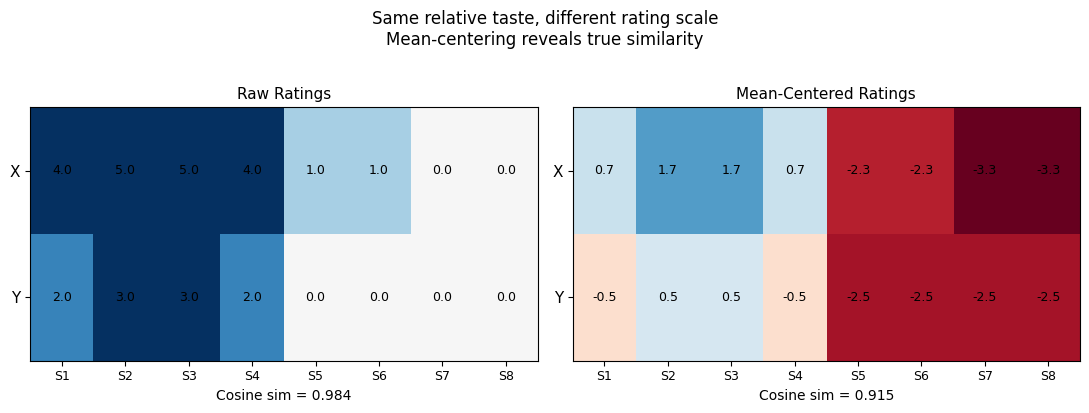

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (mat, title) in zip(axes, [
    (X_raw,      "Raw Ratings"),
    (X_centered, "Mean-Centered Ratings"),
]):
    ax.imshow(mat, cmap="RdBu", vmin=-3, vmax=3, aspect="auto")
    for i in range(2):
        for j in range(8):
            ax.text(j, i, f"{mat[i,j]:.1f}", ha="center", va="center", fontsize=9)
    ax.set_xticks(range(8))
    ax.set_xticklabels(song_ids, fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["X", "Y"], fontsize=11)
    ax.set_title(title, fontsize=11)

axes[0].set_xlabel(f"Cosine sim = {sim_raw:.3f}", fontsize=10)
axes[1].set_xlabel(f"Cosine sim = {sim_centered:.3f}", fontsize=10)
plt.suptitle("Same relative taste, different rating scale\n"
             "Mean-centering reveals true similarity", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Pitfall 3 — Cold Start

| Scenario | Problem | Which system affected? |
|---|---|---|
| New **user** | No ratings → can't build profile or find similar users | Both |
| New **item** | No ratings → CF can't include it | Collaborative filtering |
| New **item** with content | Still no ratings but features exist | Content-based handles it ✅ |

**Practical fix:** use content-based for new users/items; switch to CF once enough ratings accumulate.

### Pitfall 4 — Popularity Bias

If many users rated popular songs (S1, S2), similarity scores are dominated by those items.
Niche songs with few ratings look dissimilar to everyone — not because they're bad,
but because the cosine denominator is pulled toward the popular items.

**Fix options:** inverse-frequency weighting, exploration bonuses, or matrix factorization.

---
## Summary

| Concept | Key idea |
|---|---|
| **Utility matrix** | User × item ratings; rows = user taste vectors |
| **Item vectors** | Boolean → one-hot → standardized continuous |
| **Content-based** | User profile = avg of liked item vectors; rank by cosine sim |
| **Collaborative filtering** | User-user similarity from ratings; predict via neighbor avg |
| **Distance metric matters** | Cosine / Jaccard / binary / mean-centered → different neighbour graphs |
| **Scaling pitfall** | $\alpha \cdot$ feature changes which items are nearest |
| **Normalization pitfall** | Mean-center ratings per user before computing similarity |
| **Cold start** | CF fails for new items; content-based handles them |

**Next steps:** Can you apply both approaches to the Spotify dataset to see how these calculations play out at scale?